# Semiconductor Quality Control - Logistic Regression Analysis
---
Sequential analysis of semiconductor defects using Logistic Regression, including regularization and threshold tuning.


# 1. Imports and Setup


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, fbeta_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import matthews_corrcoef, average_precision_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 35
FOLDS = 4
FILE_PATH = 'semiconductor_quality_control.csv'


# 2. Preliminaries
## 2.1 Load Data and Cleaning


In [15]:
print(f">>> Loading Data from {FILE_PATH}...")
df = pd.read_csv(FILE_PATH)
sybau = ['Process_ID', 'Timestamp', 'Wafer_ID', 'Defect', 'Join_Status']
x = df.drop(columns=sybau)
y = df['Defect']
x = pd.get_dummies(x, columns=['Tool_Type'], drop_first=True)
print("Data Loading Done. Welcome to TSMC (not sponsored, just roleplaying). Shape : ", x.shape)


>>> Loading Data from semiconductor_quality_control.csv...
Data Loading Done. Welcome to TSMC (not sponsored, just roleplaying). Shape :  (4219, 12)


## 2.2 Train/Test Split and Normalization


In [16]:
numerical_cols = ['Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power', 'Etch_Depth',
                  'Rotation_Speed', 'Vacuum_Pressure', 'Stage_Alignment_Error',
                  'Vibration_Level', 'UV_Exposure_Intensity', 'Particle_Count']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
scaler.fit(x_train[numerical_cols])
x_train = x_train.copy()
x_test = x_test.copy()
x_train[numerical_cols] = scaler.transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

print('Pre-processing done!')


Pre-processing done!


# 3. Exploratory Data Analysis
## 3.1 Feature Importance via L1 Regression


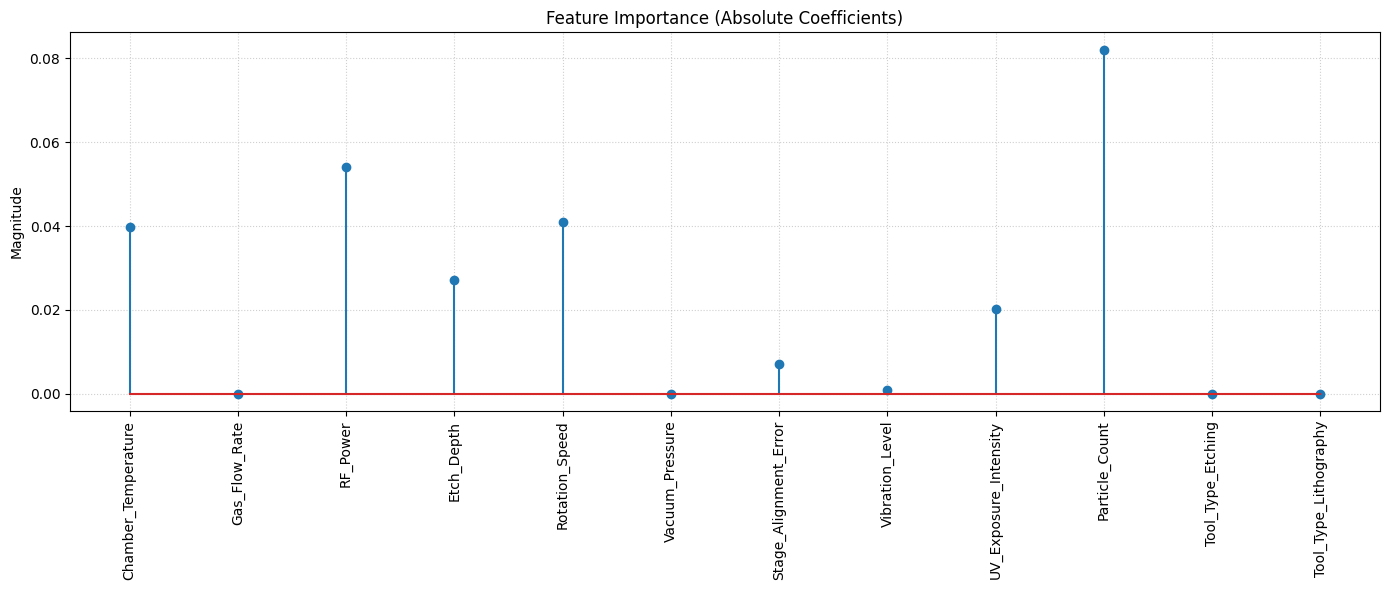

Top 5 Most Important Features:
Particle_Count: -0.0821
RF_Power: -0.0542
Rotation_Speed: -0.0409
Chamber_Temperature: 0.0397
Etch_Depth: 0.0272


In [17]:
model_eda = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', class_weight='balanced', random_state=1)
model_eda.fit(x_train, y_train)
theta_star = model_eda.coef_[0]
feature_names = x.columns

plt.figure(figsize=(14, 6))
plt.stem(np.abs(theta_star))
plt.xticks(range(len(feature_names)), feature_names, rotation=90, fontsize=10)
plt.title('Feature Importance (Absolute Coefficients)')
plt.ylabel('Magnitude')
plt.grid(linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features:")
top_indices = np.argsort(np.abs(theta_star))[::-1][:5]
for i in top_indices:
    print(f"{feature_names[i]}: {theta_star[i]:.4f}")


# 4. Baseline Modeling
## 4.1 Vanilla Logistic Regression


In [18]:
model = LogisticRegression(class_weight='balanced', C=1.0, max_iter=5000, random_state=RANDOM_STATE)
model.fit(x_train, y_train)
print('Vanilla Model Trained!')


Vanilla Model Trained!


## 4.2 Cross Validation Evaluation


In [19]:
pipeline = Pipeline([('scaler', StandardScaler()),('classifier', LogisticRegression(class_weight='balanced', C=1.0, max_iter=5000, random_state=RANDOM_STATE))])

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
f2_scorer = make_scorer(fbeta_score, beta=2)
scoring = {'recall': 'recall','precision': 'precision','f1': 'f1','accuracy': 'accuracy','f2': f2_scorer}
scores = cross_validate(pipeline, x, y, cv=cv, scoring=scoring, return_train_score=False)

print(f"{'Fold':<6} {'Recall':<10} {'F2 Score':<10} {'Precision':<10} {'F1':<10} {'Accuracy':<10}")
print("-" * 65)
for i in range(4):
    print(f"{i+1:<6} {scores['test_recall'][i]:<10.4f} {scores['test_f2'][i]:<10.4f} {scores['test_precision'][i]:<10.4f} {scores['test_f1'][i]:<10.4f} {scores['test_accuracy'][i]:<10.4f}")
print("-" * 65)
print(f"Mean Recall: {np.mean(scores['test_recall']):.4f}")
print(f"Mean F2:     {np.mean(scores['test_f2']):.4f}")


Fold   Recall     F2 Score   Precision  F1         Accuracy  
-----------------------------------------------------------------
1      0.4805     0.3327     0.1492     0.2277     0.5242    
2      0.4416     0.3083     0.1396     0.2122     0.5213    
3      0.4323     0.3034     0.1384     0.2097     0.5213    
4      0.4870     0.3345     0.1485     0.2276     0.5171    
-----------------------------------------------------------------
Mean Recall: 0.4603
Mean F2:     0.3197


# 5. Regularization Analysis
## 5.1 Grid Search over L1/L2 and C values


In [20]:
penalties = ['l1', 'l2']
C_values = np.logspace(-5, 5, 10)
results = []

print(f"{'Penalty':<10} {'C':<12} {'F2':<10} {'Recall':<12}")
print("-" * 50)

for penalty in penalties:
    for C in C_values:
        solver = 'liblinear'
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(
                penalty=penalty,
                C=C,
                solver=solver,
                class_weight='balanced',
                max_iter=5000,
                random_state=RANDOM_STATE
            ))
        ])

        cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=RANDOM_STATE)
        f2_scores = cross_val_score(pipeline, x, y, cv=cv, scoring=f2_scorer)
        rec_scores = cross_val_score(pipeline, x, y, cv=cv, scoring='recall')

        mean_f2 = np.mean(f2_scores)
        mean_rec = np.mean(rec_scores)

        results.append({'Penalty': penalty, 'C': C, 'F2': mean_f2, 'Recall': mean_rec})
        print(f"{penalty:<10} {C:<12.5f} {mean_f2:<10.4f} {mean_rec:<12.4f}")

results_df = pd.DataFrame(results)


Penalty    C            F2         Recall      
--------------------------------------------------
l1         0.00001      0.0000     0.0000      
l1         0.00013      0.0000     0.0000      
l1         0.00167      0.0000     0.0000      
l1         0.02154      0.3366     0.4959      
l1         0.27826      0.3286     0.4782      
l1         3.59381      0.3185     0.4587      
l1         46.41589     0.3197     0.4603      
l1         599.48425    0.3197     0.4603      
l1         7742.63683   0.3197     0.4603      
l1         100000.00000 0.3197     0.4603      
l2         0.00001      0.3316     0.4863      
l2         0.00013      0.3299     0.4830      
l2         0.00167      0.3308     0.4814      
l2         0.02154      0.3204     0.4620      
l2         0.27826      0.3198     0.4603      
l2         3.59381      0.3197     0.4603      
l2         46.41589     0.3197     0.4603      
l2         599.48425    0.3197     0.4603      
l2         7742.63683   0.3197     0.

## 5.2 Regularization Impact Visualization


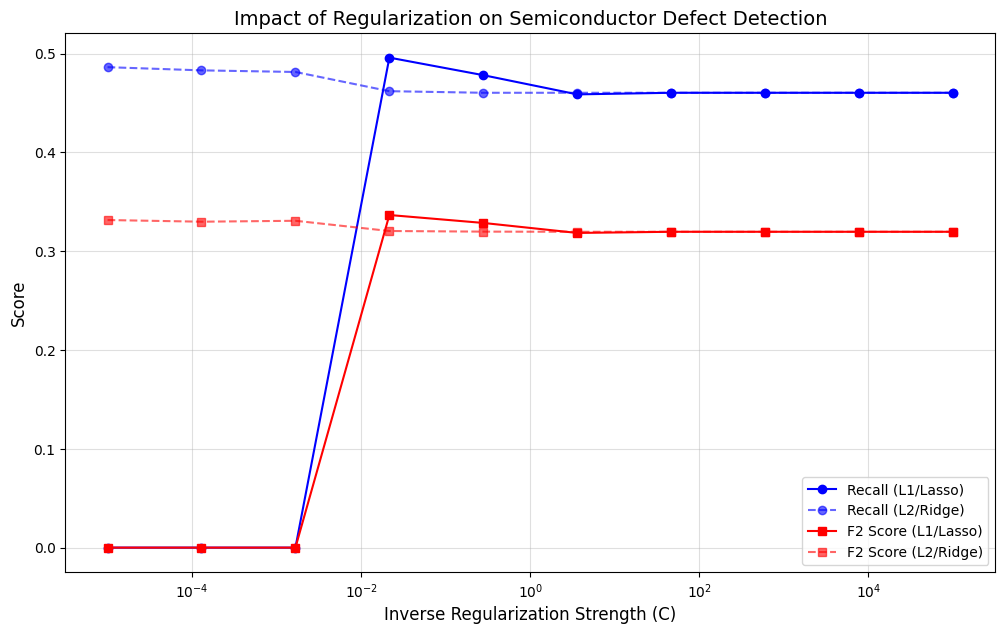

In [21]:
plt.figure(figsize=(12, 7))

df_l1 = results_df[results_df['Penalty'] == 'l1']
df_l2 = results_df[results_df['Penalty'] == 'l2']

plt.plot(df_l1['C'], df_l1['Recall'], label='Recall (L1/Lasso)', color='blue', marker='o', linestyle='-')
plt.plot(df_l2['C'], df_l2['Recall'], label='Recall (L2/Ridge)', color='blue', marker='o', linestyle='--', alpha=0.6)
plt.plot(df_l1['C'], df_l1['F2'], label='F2 Score (L1/Lasso)', color='red', marker='s', linestyle='-')
plt.plot(df_l2['C'], df_l2['F2'], label='F2 Score (L2/Ridge)', color='red', marker='s', linestyle='--', alpha=0.6)

plt.xscale('log')
plt.xlabel('Inverse Regularization Strength (C)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Impact of Regularization on Semiconductor Defect Detection', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.show()


## 5.3 Regularization Path (L1)


Running regularization path...
Best C: 0.0281 | Best F2: 0.3443


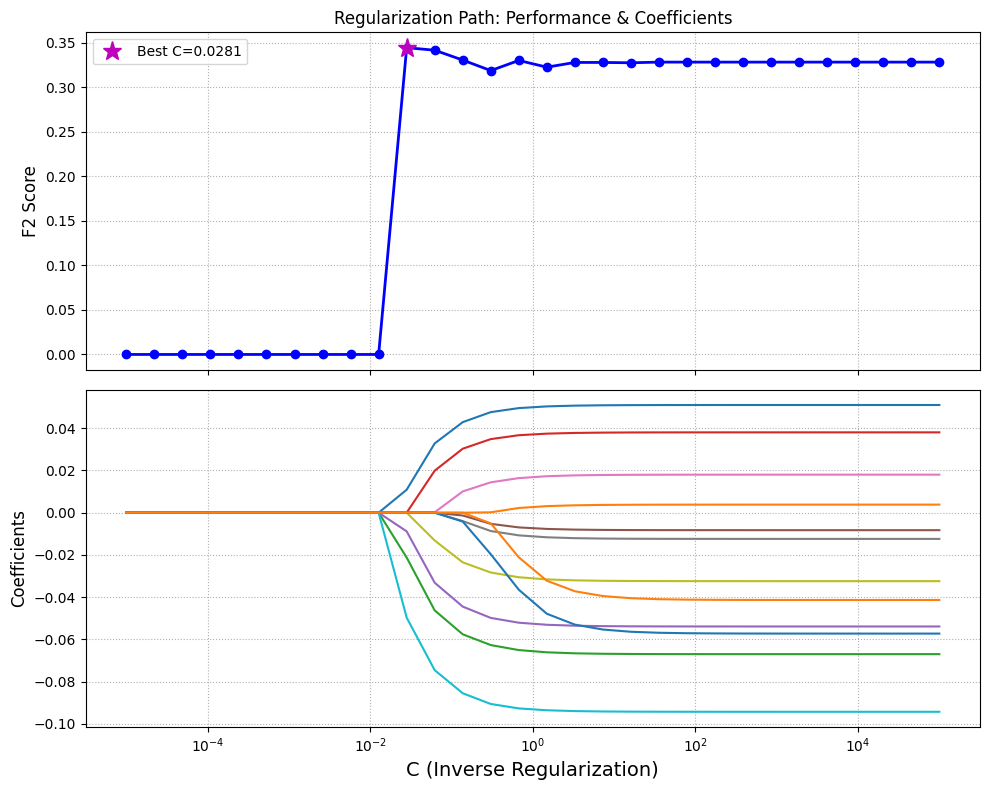

In [22]:
Cs = np.logspace(-5, 5, 30)
coefs = []
f2_scores = []
print("Running regularization path...")

for C in Cs:
    model = LogisticRegression(penalty='l1', C=C, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
    model.fit(x_train, y_train)
    coefs.append(model.coef_[0])
    y_pred = model.predict(x_test)
    f2_scores.append(fbeta_score(y_test, y_pred, beta=2))

coefs = np.array(coefs)
f2_scores = np.array(f2_scores)
best_idx = np.argmax(f2_scores)
best_C = Cs[best_idx]
best_f2 = f2_scores[best_idx]

print(f"Best C: {best_C:.4f} | Best F2: {best_f2:.4f}")

fig, ax = plt.subplots(figsize=(10, 8), nrows=2, sharex=True)
ax[0].semilogx(Cs, f2_scores, 'o-', color='b', linewidth=2)
ax[0].semilogx(best_C, best_f2, '*', color='m', markersize=14, label=f'Best C={best_C:.4f}')
ax[0].set_ylabel('F2 Score', fontsize=12)
ax[0].grid(linestyle=':')
ax[0].legend()
ax[0].set_title('Regularization Path: Performance & Coefficients')

ax[1].semilogx(Cs, coefs)
ax[1].set_xlabel('C (Inverse Regularization)', fontsize=14)
ax[1].set_ylabel('Coefficients', fontsize=12)
ax[1].grid(linestyle=':')
plt.tight_layout()
plt.show()


# 6. Threshold Tuning


In [23]:
print("Tuning Threshold on best model...")
best_model = LogisticRegression(penalty='l1', C=best_C, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
best_model.fit(x_train, y_train)
y_probs = best_model.predict_proba(x_test)[:, 1]

best_score = 0
best_thresh = 0.5

for t in np.arange(0.1, 0.9, 0.05):
    temp_pred = (y_probs >= t).astype(int)
    fbeta = fbeta_score(y_test, temp_pred, beta=2)
    if fbeta > best_score:
        best_score = fbeta
        best_thresh = t

print(f"Best Threshold: {best_thresh:.2f}")
print(f"Best F2 Score:  {best_score:.4f}")


Tuning Threshold on best model...
Best Threshold: 0.10
Best F2 Score:  0.4603


# 7. Model Comparison

### Matthews Correlation Coefficient (MCC)

MCC is a metric that accounts for all four quadrants of the confusion matrix, making it robust to class imbalance. Unlike accuracy or recall alone, MCC only gives a high score when the model performs well on **both** positive and negative classes.

$$\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

Where TP = True Positives, TN = True Negatives, FP = False Positives, FN = False Negatives.

**Interpretation:**
- **+1**: Perfect prediction
- **0**: No better than random guessing
- **-1**: Complete disagreement (predictions are inverted)

MCC is particularly useful here because a model that predicts all samples as "Defect" would achieve high recall but MCC ≈ 0, exposing the lack of true predictive power.


In [24]:
# 1. Vanilla (C=1.0, threshold=0.5)
vanilla_model = LogisticRegression(class_weight='balanced', C=1.0, max_iter=5000, random_state=RANDOM_STATE)
vanilla_model.fit(x_train, y_train)
vanilla_probs = vanilla_model.predict_proba(x_test)[:, 1]
vanilla_preds = (vanilla_probs >= 0.5).astype(int)

# 2. Best C (L1, tuned C, threshold=0.5)
best_c_model = LogisticRegression(penalty='l1', C=best_C, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE)
best_c_model.fit(x_train, y_train)
best_c_probs = best_c_model.predict_proba(x_test)[:, 1]
best_c_preds = (best_c_probs >= 0.5).astype(int)

# 3. Best C + Threshold tuning
best_thresh_preds = (best_c_probs >= best_thresh).astype(int)

def get_metrics(y_true, y_pred, y_prob):
    return {
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F2': fbeta_score(y_true, y_pred, beta=2),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
    }

comparison = pd.DataFrame({
    'Vanilla (C=1.0, t=0.5)': get_metrics(y_test, vanilla_preds, vanilla_probs),
    f'Best C={best_C:.4f}, t=0.5': get_metrics(y_test, best_c_preds, best_c_probs),
    f'Best C + t={best_thresh:.2f}': get_metrics(y_test, best_thresh_preds, best_c_probs)
}).T

print(comparison.round(4).to_string())


                           MCC  Recall      F2  Accuracy  Precision
Vanilla (C=1.0, t=0.5)  0.0039  0.4715  0.3273    0.5249     0.1472
Best C=0.0281, t=0.5    0.0091  0.5122  0.3443    0.5024     0.1489
Best C + t=0.10         0.0000  1.0000  0.4603    0.1457     0.1457


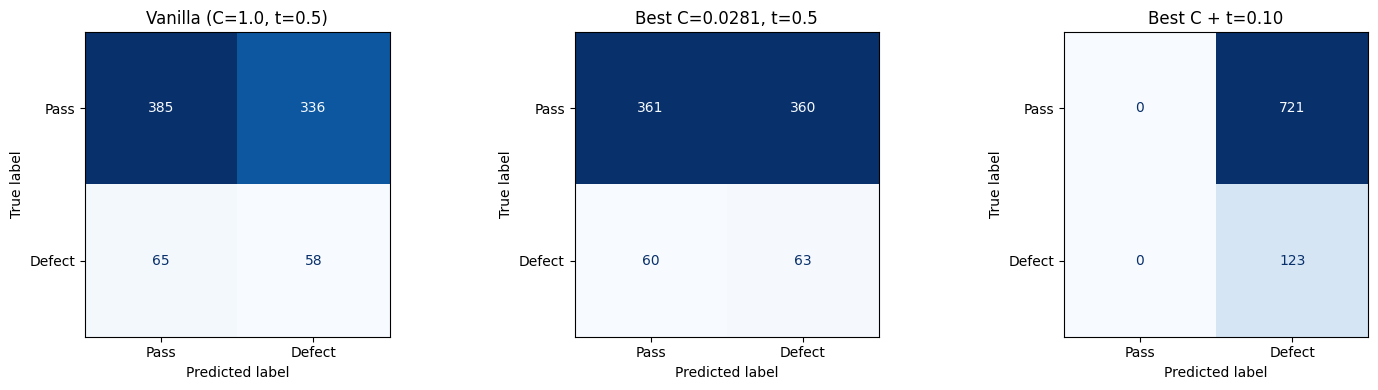

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Vanilla (C=1.0, t=0.5)', f'Best C={best_C:.4f}, t=0.5', f'Best C + t={best_thresh:.2f}']
preds_list = [vanilla_preds, best_c_preds, best_thresh_preds]

for ax, preds, title in zip(axes, preds_list, titles):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Defect'])
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(title)
    ax.grid(False)

plt.tight_layout()
plt.show()


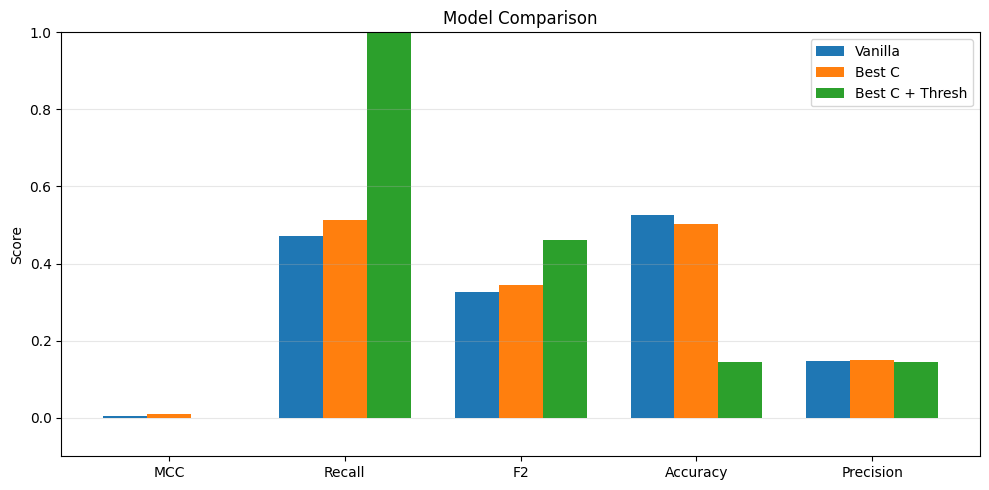

In [26]:
metrics = ['MCC', 'Recall', 'F2', 'Accuracy', 'Precision', ]
x_pos = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_pos - width, comparison.iloc[0], width, label='Vanilla')
ax.bar(x_pos, comparison.iloc[1], width, label='Best C')
ax.bar(x_pos + width, comparison.iloc[2], width, label='Best C + Thresh')

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend()
ax.set_ylim(-0.1, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


The low MCC score across all models indicates that while the models perform well on metrics like Recall and F2 Score, they struggle with overall balanced classification performance. This suggests that the models may be biased towards one class depending on how the model is tuned, leading to either a high number of false positives or false negatives. Hence, logistic regression, even with tuning, may not be sufficient for this imbalanced classification task, and we will move on to exploring more advanced models to achieve better performance. 